# The contract of a discrete map

`si.rk4`, `si.explicit` and every other integrator in `scaly.integrators` turn a continuous-time
model $x' = f(x, \dots)$ into a discrete map $x_{\text{next}} = F(x, \dots)$, a `Function` like any
other. This notebook checks what that map promises, one clause at a time, on a pendulum driven by a
torque with a friction parameter: its signature and name, the zero-order hold on every input after
the state, the interval as an input, substeps that turn into a loop, two maps of one model in one
Function, the map's derivatives, and a template model that gives one map per state size.

| Scaly feature | Where |
| --- | --- |
| `si.rk4(model, dt=..., name=...)`, `input_names`, `output_names` | The model and its map |
| every input after the state held over the interval | A zero-order hold |
| `dt=None` | The interval as an input |
| `steps=`, `si.UNROLL_STEPS`, `sc.scan`, `render_c_module` | Substeps: unrolled, then a loop |
| `si.explicit(model, "dopri5", steps=...)` inside an `sc.function` | Two maps in one Function |
| `sc.jacobian`, `si.linearize`, `si.zoh` | Derivatives |
| a template model, `.instances` | A template map |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import expm

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
import scaly as sc
from scaly import integrators as si
from scaly.codegen import render_c_module, write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "integrators" / "discrete_maps"

## The model and its map

A pendulum of length $\ell = 0.5$ m, driven by a torque $u$ per unit inertia and damped by viscous
friction with coefficient $c$:

$$
\ddot\theta = -\frac{g}{\ell} \sin\theta - c\,\dot\theta + u, \qquad x = (\theta, \dot\theta) .
$$

A model is a `Function` whose first input is the state and whose one output is its derivative;
here `pendulum(x, u, friction) -> xdot`. `F = si.rk4(pendulum, dt=DT)` has the model's own
signature with `xnext` as its output, and is named `{model}_rk4` unless `name=` says otherwise.

In [2]:
G_OVER_L = 9.81 / 0.5
FRICTION = 0.3
DT = 0.1


@sc.function(2, 1, (), output="xdot", name="discrete_maps_pendulum")
def pendulum(x, u, friction):
  return sc.stack([x[1], -G_OVER_L * x[0].sin() - friction * x[1] + u[0]])


def pendulum_np(x, u, friction):
  return [x[1], -G_OVER_L * np.sin(x[0]) - friction * x[1] + u[0]]


def flow(x, u, friction=FRICTION, span=DT):
  """The model's exact flow over ``span`` with ``u`` held, to about 1e-14."""
  return solve_ivp(lambda t, y: pendulum_np(y, u, friction), (0, span), x, method="DOP853", rtol=1e-13, atol=1e-13).y[:, -1]


step = si.rk4(pendulum, dt=DT)
named = si.rk4(pendulum, dt=DT, name="discrete_maps_plant")
friction = np.array(FRICTION)
X0, U0 = np.array([2.5, 0.0]), np.array([1.5])
print(f"{step.name}{step.input_names} -> {step.output_names}")
print(f"with name=: {named.name}")
print(f"F(x0, u0, c) = {step(X0, U0, friction)}, one RK4 step of {DT} s")

discrete_maps_pendulum_rk4('x', 'u', 'friction') -> ('xnext',)
with name=: discrete_maps_plant


F(x0, u0, c) = [ 2.44863385 -1.03503842], one RK4 step of 0.1 s


## A zero-order hold

Every input after the state is held constant over the interval: between $t_k$ and $t_k + \Delta t$
the map integrates $x' = f(x, u_k, c)$. To check that clause apart from RK4's own error, a map with
500 substeps stands in for the exact flow. Over twenty intervals, each with its own torque $u_k$,
it must follow `solve_ivp` restarted at every interval with $u_k$ held.

20 intervals of the 500-substep map against solve_ivp, largest error 3.4e-13


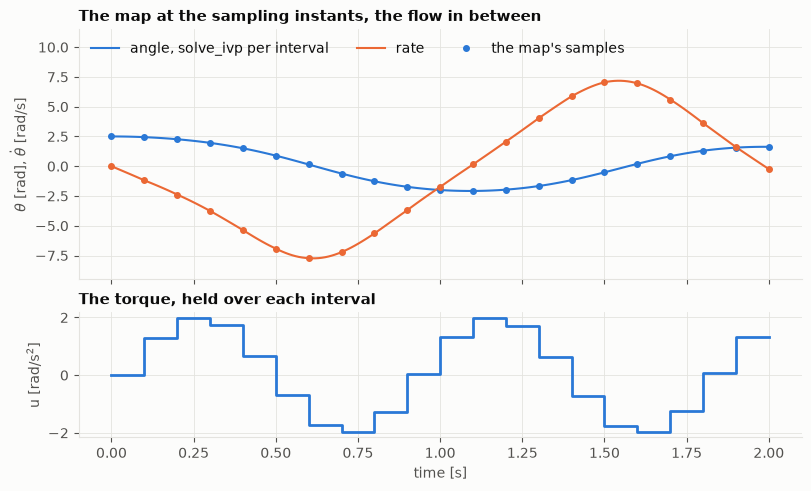

In [3]:
MANY = 500
INTERVALS = 20
many = si.rk4(pendulum, dt=DT, steps=MANY, name=f"discrete_maps_pendulum_rk4_x{MANY}")

torques = 2.0 * np.sin(0.7 * np.arange(INTERVALS))[:, None]
x, exact, zoh_error = X0, X0, 0.0
mapped, curves = [X0], []
for u in torques:
  piece = solve_ivp(lambda t, y, u=u: pendulum_np(y, u, FRICTION), (0, DT), exact, method="DOP853", rtol=1e-13, atol=1e-13, dense_output=True)
  curves.append(piece.sol(np.linspace(0, DT, 11)))
  x, exact = many(x, u, friction), piece.y[:, -1]
  mapped.append(x)
  zoh_error = max(zoh_error, float(np.abs(x - exact).max()))
mapped = np.array(mapped)
print(f"{INTERVALS} intervals of the {MANY}-substep map against solve_ivp, largest error {zoh_error:.1e}")

t = DT * np.arange(INTERVALS + 1)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4.8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
for k, curve in enumerate(curves):
  times = t[k] + np.linspace(0, DT, 11)
  ax1.plot(times, curve[0], color=plotstyle.BLUE, lw=1.5, label="angle, solve_ivp per interval" if k == 0 else None)
  ax1.plot(times, curve[1], color=plotstyle.ORANGE, lw=1.5, label="rate" if k == 0 else None)
ax1.plot(t, mapped[:, 0], "o", color=plotstyle.BLUE, ms=4, label="the map's samples")
ax1.plot(t, mapped[:, 1], "o", color=plotstyle.ORANGE, ms=4)
ax1.set_ylabel(r"$\theta$ [rad], $\dot\theta$ [rad/s]")
ax1.set_title("The map at the sampling instants, the flow in between")
ax1.set_ylim(-9.5, 11.5)
ax1.legend(loc="upper left", ncols=3)
ax2.step(t, np.r_[torques[:, 0], torques[-1, 0]], where="post", color=plotstyle.BLUE)
ax2.set_ylabel(r"u [rad/s$^2$]")
ax2.set_xlabel("time [s]")
ax2.set_title("The torque, held over each interval")
plt.show()

The map's samples sit on the flow to $3 \times 10^{-13}$ at every one of the twenty instants.

## The interval as an input

`dt=None` appends a `dt` input: `F(x, u, friction, dt)`. That serves free-final-time problems and
sampling intervals that change at run time. At `dt = DT` it returns exactly what the map with the
interval folded in returns. One compiled Function also covers a sweep over the interval: RK4's
local error, the error of one step from an exact state, falls as $\Delta t^5$.

discrete_maps_pendulum_rk4_dt('x', 'u', 'friction', 'dt'); at dt = 0.1 against the folded interval: 0.0e+00
one-step error from 2.9e-09 at dt = 0.01 to 1.7e-01 at dt = 0.4; slope below dt = 0.05: 4.99


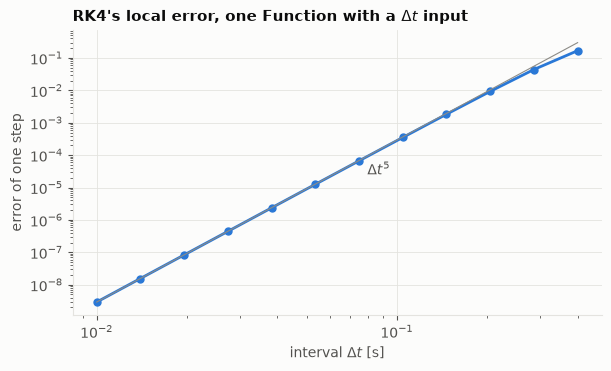

In [4]:
timed = si.rk4(pendulum, dt=None, name="discrete_maps_pendulum_rk4_dt")
dt_input_difference = float(np.abs(timed(X0, U0, friction, np.array(DT)) - step(X0, U0, friction)).max())
print(f"{timed.name}{timed.input_names}; at dt = {DT} against the folded interval: {dt_input_difference:.1e}")

spans = np.geomspace(0.01, 0.4, 12)
local = [float(np.abs(timed(X0, U0, friction, np.array(span)) - flow(X0, U0, span=span)).max()) for span in spans]
rate = np.polyfit(np.log(spans[:6]), np.log(local[:6]), 1)[0]
print(f"one-step error from {local[0]:.1e} at dt = {spans[0]} to {local[-1]:.1e} at dt = {spans[-1]}; slope below dt = {spans[5]:.2f}: {rate:.2f}")

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.loglog(spans, local, "o-", color=plotstyle.BLUE)
ax.loglog(spans, local[0] * (spans / spans[0]) ** 5, color=plotstyle.NEUTRAL, lw=0.8)
ax.annotate(
  r"$\Delta t^5$", (spans[6], local[0] * (spans[6] / spans[0]) ** 5), xytext=(6, -10), textcoords="offset points", color=plotstyle.TEXT_SECONDARY
)
ax.set_xlabel(r"interval $\Delta t$ [s]")
ax.set_ylabel("error of one step")
ax.set_title(r"RK4's local error, one Function with a $\Delta t$ input")
plt.show()

The difference is exactly zero: with `dt=None` the map divides the same interval into the same
weights at run time. The local error follows $\Delta t^5$, with a fitted slope of 4.99 below
$\Delta t = 0.05$ s, and bends below that line beyond 0.2 s, where $\Delta t\, \omega_0$ with
$\omega_0 = \sqrt{g/\ell} \approx 4.4$ rad/s is no longer small.

## Substeps: unrolled, then a loop

`steps=n` divides the interval into $n$ equal RK4 substeps. Up to `si.UNROLL_STEPS` substeps are
unrolled into straight-line code, so the C grows with $n$. More run as a `sc.scan`, a loop in the
generated C over one substep Function, so the C has the same length for 5 and for 500 substeps. The
error against the flow falls as $n^{-4}$, RK4's global order.

si.UNROLL_STEPS = 4
 steps  C lines     error
     1       61   2.8e-04
     2       85   1.8e-05
     4      133   1.1e-06
     5       59   4.6e-07
    50       59   4.7e-11
   500       59   8.7e-15


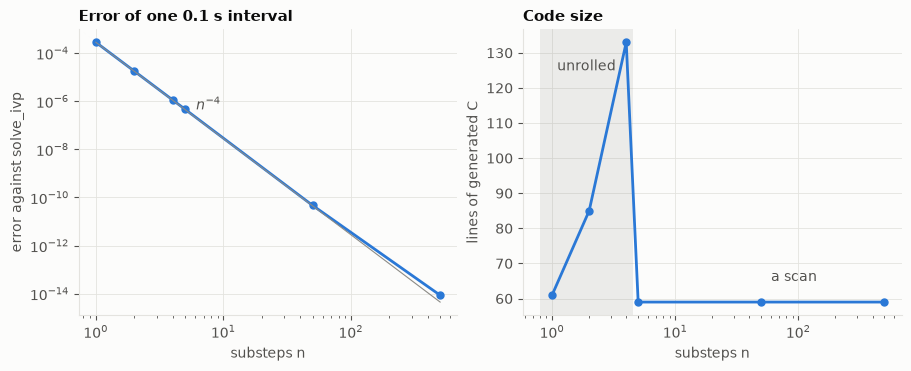

In [5]:
SUBSTEPS = (1, 2, 4, 5, 50, 500)
exact = flow(X0, U0)
c_lines, substep_errors = {}, {}
for n in SUBSTEPS:
  fn = step if n == 1 else many if n == MANY else si.rk4(pendulum, dt=DT, steps=n, name=f"discrete_maps_pendulum_rk4_x{n}")
  c_lines[n] = len(render_c_module(fn).source.splitlines())
  substep_errors[n] = float(np.abs(fn(X0, U0, friction) - exact).max())
print(f"si.UNROLL_STEPS = {si.UNROLL_STEPS}")
print(f"{'steps':>6} {'C lines':>8} {'error':>9}")
for n in SUBSTEPS:
  print(f"{n:>6} {c_lines[n]:>8} {substep_errors[n]:>9.1e}")

ns = np.array(SUBSTEPS)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.6))
ax1.loglog(ns, list(substep_errors.values()), "o-", color=plotstyle.BLUE)
ax1.loglog(ns, substep_errors[1] * ns**-4.0, color=plotstyle.NEUTRAL, lw=0.8)
ax1.annotate(r"$n^{-4}$", (ns[3], substep_errors[1] * ns[3] ** -4.0), xytext=(8, 0), textcoords="offset points", color=plotstyle.TEXT_SECONDARY)
ax1.set_xlabel("substeps n")
ax1.set_ylabel("error against solve_ivp")
ax1.set_title(f"Error of one {DT} s interval")
ax2.semilogx(ns, list(c_lines.values()), "o-", color=plotstyle.BLUE)
ax2.axvspan(0.8, si.UNROLL_STEPS + 0.5, color=plotstyle.NEUTRAL, alpha=0.15, lw=0)
ax2.annotate("unrolled", (1.1, max(c_lines.values()) - 8), color=plotstyle.TEXT_SECONDARY)
ax2.annotate("a scan", (60, min(c_lines.values()) + 6), color=plotstyle.TEXT_SECONDARY)
ax2.set_xlabel("substeps n")
ax2.set_ylabel("lines of generated C")
ax2.set_title("Code size")
plt.show()

Each doubling up to four substeps divides the error by 16, and 500 substeps reach
$9 \times 10^{-15}$. Unrolled, each substep adds 24 lines of C; from five substeps on, the source
is 59 lines whatever the count, two fewer than the single step, because the substep becomes one
function that the loop calls.

## Two maps in one Function

A map is a `Function`, so two maps of one model can be called in a third. The RK4 step minus a
DOPRI5 map with 50 substeps estimates RK4's local error, since DOPRI5's own error over the interval
is near rounding. The two maps need distinct names, since the generated code has one procedure per
name; their default names carry the method, `discrete_maps_pendulum_rk4` and
`discrete_maps_pendulum_dopri5`, so they differ.

discrete_maps_pendulum_dopri5 and discrete_maps_pendulum_rk4 in discrete_maps_local_error
RK4 local error up to 4.9e-04 at 8 states; the estimate misses it by 4.9e-13
over the grid: from 6.5e-06 to 1.9e-03; at rest 4.7e-05


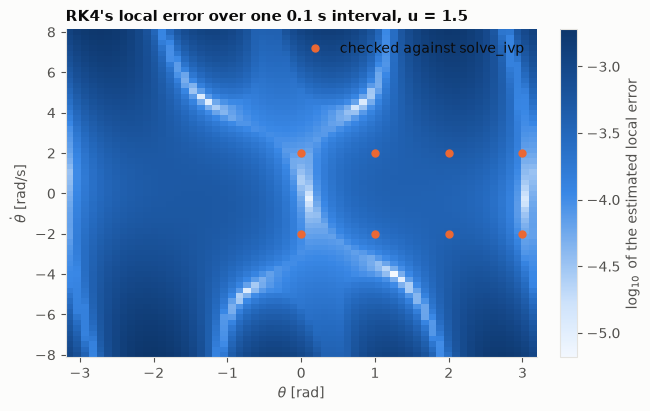

In [6]:
reference = si.explicit(pendulum, "dopri5", dt=DT, steps=50)


@sc.function(2, 1, (), output="local_error", name="discrete_maps_local_error")
def local_error(x, u, friction):
  return step(x, u, friction) - reference(x, u, friction)


states = [np.array([a, w]) for a in (0.0, 1.0, 2.0, 3.0) for w in (-2.0, 2.0)]
estimates = [local_error(s, U0, friction) for s in states]
true_errors = [step(s, U0, friction) - flow(s, U0) for s in states]
local_error_largest = max(float(np.abs(e).max()) for e in true_errors)
local_error_mismatch = max(float(np.abs(e - t).max()) for e, t in zip(estimates, true_errors, strict=True))
print(f"{reference.name} and {step.name} in {local_error.name}")
print(f"RK4 local error up to {local_error_largest:.1e} at 8 states; the estimate misses it by {local_error_mismatch:.1e}")

GRID = 61
angles, rates = np.linspace(-np.pi, np.pi, GRID), np.linspace(-8.0, 8.0, GRID)
field = np.array([[np.abs(local_error(np.array([a, w]), U0, friction)).max() for a in angles] for w in rates])
print(f"over the grid: from {field.min():.1e} to {field.max():.1e}; at rest {np.abs(local_error(np.zeros(2), U0, friction)).max():.1e}")
fig, ax = plt.subplots(figsize=(6.4, 4))
image = ax.pcolormesh(angles, rates, np.log10(field), cmap=plotstyle.BLUES, shading="auto")
fig.colorbar(image, ax=ax, label=r"$\log_{10}$ of the estimated local error")
ax.plot([s[0] for s in states], [s[1] for s in states], "o", color=plotstyle.ORANGE, ms=5, label="checked against solve_ivp")
ax.set_xlabel(r"$\theta$ [rad]")
ax.set_ylabel(r"$\dot\theta$ [rad/s]")
ax.set_title(f"RK4's local error over one {DT} s interval, u = {U0[0]}")
ax.legend(loc="upper right")
ax.grid(False)
plt.show()

At the eight checked states the estimate matches the true local error to $5 \times 10^{-13}$, the
error of the 50-substep DOPRI5 map itself. Over the state plane the estimate is largest, near
$2 \times 10^{-3}$, at high speed and at angles near $\pm\pi$, where the pendulum's acceleration
changes fastest. The light curves are where one component of the error changes sign.

## Derivatives

`sc.jacobian(F, "x")` and `sc.jacobian(F, "dt")` differentiate through the four calls of the
model, forward mode through its generated derivative. Central differences agree with them only to
the extent their step allows: the truncation error falls as $\varepsilon^2$ and the rounding error
grows as $10^{-16}/\varepsilon$, so the best agreement comes near $\varepsilon = 10^{-5}$.

dF/dx at x0:
[[1.07831197 0.10107023]
 [1.56763635 1.0469735 ]]
against central differences with eps = 1e-6: in x 3.4e-10, in dt 5.2e-11
the closest agreement, 1.8e-11, at eps = 1.0e-05


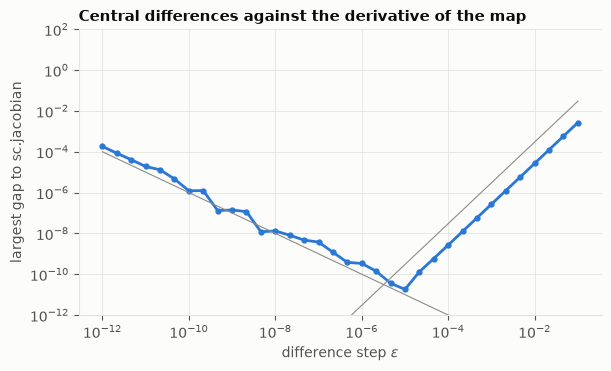

In [7]:
def central(fn, args, k, eps=1e-6):
  """The Jacobian of ``fn`` in its ``k``-th argument by central differences."""
  columns = []
  for i in range(args[k].size):
    plus, minus = [a.copy() for a in args], [a.copy() for a in args]
    plus[k].flat[i] += eps
    minus[k].flat[i] -= eps
    columns.append((fn(*plus) - fn(*minus)) / (2 * eps))
  return np.stack(columns, axis=-1).reshape(-1, args[k].size)


args = [X0, U0, friction]
jac_x = sc.jacobian(step, "x")(*args)
jac_x_error = float(np.abs(jac_x - central(step, args, 0)).max())
timed_args = [X0, U0, friction, np.array(DT)]
jac_dt_error = float(np.abs(sc.jacobian(timed, "dt")(*timed_args) - central(timed, timed_args, 3)).max())
print(f"dF/dx at x0:\n{jac_x}")
print(f"against central differences with eps = 1e-6: in x {jac_x_error:.1e}, in dt {jac_dt_error:.1e}")

epsilons = np.geomspace(1e-12, 1e-1, 34)
gaps = [float(np.abs(jac_x - central(step, args, 0, eps)).max()) for eps in epsilons]
print(f"the closest agreement, {min(gaps):.1e}, at eps = {epsilons[int(np.argmin(gaps))]:.1e}")
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.loglog(epsilons, gaps, "o-", color=plotstyle.BLUE, ms=3.5)
ax.loglog(epsilons, 1e-16 / epsilons, color=plotstyle.NEUTRAL, lw=0.8)
ax.loglog(epsilons, 3.0 * epsilons**2, color=plotstyle.NEUTRAL, lw=0.8)
ax.set_ylim(1e-12, 1e2)
ax.set_xlabel(r"difference step $\varepsilon$")
ax.set_ylabel("largest gap to sc.jacobian")
ax.set_title("Central differences against the derivative of the map")
plt.show()

The differences meet the derivative at $3 \times 10^{-10}$ in $x$ and $5 \times 10^{-11}$ in $\Delta t$
with $\varepsilon = 10^{-6}$. The sweep's floor, $2 \times 10^{-11}$ at $\varepsilon = 10^{-5}$,
sits where the two thin lines, $\varepsilon^2$ truncation and $10^{-16}/\varepsilon$ rounding,
cross.

### Linearization at an equilibrium

`si.linearize(F, x, u, friction)` evaluates the Jacobians of the map's one output in each input
leaf: `(Ad, Bd, Cd)`, the last one the sensitivity to the friction coefficient. At an angle
$\theta^\star$ held by the constant torque $u^\star = (g/\ell)\sin\theta^\star$ the pendulum stays
put, so the Jacobians of its flow are exactly those of the linearized model's flow,
$\delta x' = A\, \delta x + B\, \delta u$. `si.zoh` computes that exactly from one matrix exponential, and the
500-substep map must agree with it to rounding. The friction column is zero there, since friction
acts through the velocity and the velocity is zero.

In [8]:
EQUILIBRIUM_ANGLE = 0.5
x_eq, u_eq = np.array([EQUILIBRIUM_ANGLE, 0.0]), np.array([G_OVER_L * np.sin(EQUILIBRIUM_ANGLE)])
ad, bd, cd = si.linearize(many, x_eq, u_eq, friction)
a, b, c = si.linearize(pendulum, x_eq, u_eq, friction)
zoh_ad, zoh_bd = si.zoh(a, b, DT)
point = [x_eq, u_eq, friction]
linearize_fd_error = max(float(np.abs(m - central(many, point, k)).max()) for k, m in enumerate((ad, bd, cd)))
linearize_zoh_error = max(float(np.abs(ad - zoh_ad).max()), float(np.abs(bd - zoh_bd).max()))
print(f"the model at theta = {EQUILIBRIUM_ANGLE}: A = {a.tolist()}, B = {b.ravel().tolist()}")
print(f"the map: shapes {[m.shape for m in (ad, bd, cd)]}")
print(f"Ad = {ad.tolist()}\nBd = {bd.ravel().tolist()}, Cd = {cd.ravel().tolist()}")
print(f"against central differences: {linearize_fd_error:.1e}; (Ad, Bd) against si.zoh(A, B, {DT}): {linearize_zoh_error:.1e}")

the model at theta = 0.5: A = [[0.0, 1.0], [-17.218169864289113, -0.3]], B = [0.0, 1.0]
the map: shapes [(2, 2), (2, 1), (2, 1)]
Ad = [[0.915977222801658, 0.0957120922650793], [-1.6479870626866464, 0.887263595122134]]
Bd = [0.004879890131215814, 0.0957120922650793], Cd = [0.0, 0.0]
against central differences: 7.1e-10; (Ad, Bd) against si.zoh(A, B, 0.1): 7.1e-15


The map's linearization matches the exact discretization of the model's linearization to
$7 \times 10^{-15}$, and central differences to $7 \times 10^{-10}$.

## A template map

A model declared without shapes, `@sc.function(output="xdot")`, is a template: each call with new
shapes traces one instance. Its map is a template too. Here a chain of $n$ unit masses joined by
springs of stiffness $k$, the outer two tied to walls, with $x = (q, v)$ and

$$
q_i'' = k\,(q_{i-1} - 2 q_i + q_{i+1}), \qquad q_0 = q_{n+1} = 0 ,
$$

a linear system whose exact flow is a matrix exponential. The model reads $n$ off the size of its
state, so one definition serves 3 masses and 10.

discrete_maps_chain_rk4: concrete False, instances ['discrete_maps_chain__6_s_rk4', 'discrete_maps_chain__20_s_rk4']
  state size  6: one interval against expm, 2.3e-08
  state size 20: one interval against expm, 1.9e-08


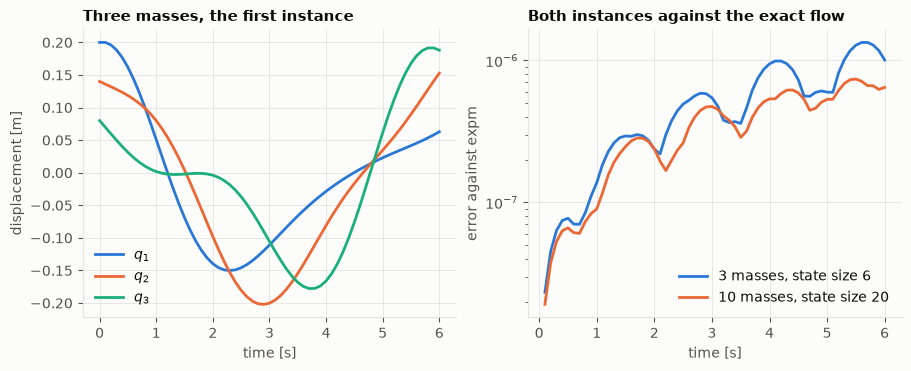

In [9]:
STIFFNESS = 1.5
CHAIN_MASSES = (3, 10)
CHAIN_STEPS = 60


@sc.function(output="xdot", name="discrete_maps_chain")
def chain(x, k):
  n = x.shape[0] // 2
  q, v = x[:n], x[n:]
  wall = sc.const(np.zeros(1))
  padded = sc.concat([wall, q, wall])
  return sc.concat([v, k * (padded[:-2] - 2 * q + padded[2:])])


chain_step = si.rk4(chain, dt=DT, steps=2)
template_errors, paths = {}, {}
for n in CHAIN_MASSES:
  lap = -2 * np.eye(n) + np.eye(n, k=1) + np.eye(n, k=-1)
  system = np.block([[np.zeros((n, n)), np.eye(n)], [STIFFNESS * lap, np.zeros((n, n))]])
  x0 = np.linspace(0.2, -0.1, 2 * n)
  template_errors[2 * n] = float(np.abs(chain_step(x0, np.array(STIFFNESS)) - expm(system * DT) @ x0).max())
  xs, errors = [x0], [0.0]
  for j in range(1, CHAIN_STEPS + 1):
    xs.append(chain_step(xs[-1], np.array(STIFFNESS)))
    errors.append(float(np.abs(xs[-1] - expm(system * DT * j) @ x0).max()))
  paths[n] = (np.array(xs), np.array(errors))
print(f"{chain_step.name}: concrete {chain_step.is_concrete}, instances {list(chain_step.instances)}")
for size, error in template_errors.items():
  print(f"  state size {size:>2}: one interval against expm, {error:.1e}")

t = DT * np.arange(CHAIN_STEPS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.6))
for i, color in enumerate((plotstyle.BLUE, plotstyle.ORANGE, plotstyle.AQUA)):
  ax1.plot(t, paths[3][0][:, i], color=color, label=f"$q_{i + 1}$")
ax1.set_xlabel("time [s]")
ax1.set_ylabel("displacement [m]")
ax1.set_title("Three masses, the first instance")
ax1.legend(loc="lower left")
for n, color in zip(CHAIN_MASSES, (plotstyle.BLUE, plotstyle.ORANGE), strict=True):
  ax2.semilogy(t[1:], paths[n][1][1:], color=color, label=f"{n} masses, state size {2 * n}")
ax2.set_xlabel("time [s]")
ax2.set_ylabel("error against expm")
ax2.set_title("Both instances against the exact flow")
ax2.legend(loc="lower right")
plt.show()

The template map `discrete_maps_chain_rk4` is not concrete; its two instances, traced on the
first call at each size, are `discrete_maps_chain__6_s_rk4` and `discrete_maps_chain__20_s_rk4`,
with the size in the name. Both are within $2.3 \times 10^{-8}$ of the matrix exponential after one
interval, and the error grows roughly in proportion to the number of intervals, to $10^{-6}$ after
sixty.

## Checks

In [10]:
assert step.input_names == ("x", "u", "friction") and step.output_names == ("xnext",)
assert timed.input_names == ("x", "u", "friction", "dt") and dt_input_difference < 1e-15
assert step.name.endswith("_rk4") and named.name != step.name
assert zoh_error < 5e-12
assert si.UNROLL_STEPS == 4
assert c_lines[1] < c_lines[2] < c_lines[4] and c_lines[5] == c_lines[50] == c_lines[500]  # a scan beyond four substeps
errors = substep_errors
assert abs(np.log2(errors[1] / errors[2]) - 4) < 0.2 and abs(np.log2(errors[2] / errors[4]) - 4) < 0.2
assert errors[5] > errors[50] > errors[500] and errors[500] < 1e-13
assert local_error_largest > 1e-4 and local_error_mismatch < 5e-12
assert jac_x_error < 5e-9 and jac_dt_error < 1e-9
assert [m.shape for m in (ad, bd, cd)] == [(2, 2), (2, 1), (2, 1)]
assert linearize_fd_error < 1e-8 and linearize_zoh_error < 1e-13 and np.abs(cd).max() < 1e-15
assert len(chain_step.instances) == 2 and all(e < 3e-7 for e in template_errors.values())
print("13 checks passed")

13 checks passed


## The generated C

The one-step map, and the 500-substep map with its loop. In the second, the substep is a
`static inline` function and the interval's 500 substeps are one `for` loop over it, alternating
between two halves of a workspace for the carry.

In [11]:
for fn in (step, many):
  module = write_module(fn, GENERATED)
  print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.1f} kB")
lines = module.source.splitlines()
start = next(i for i, line in enumerate(lines) if line.startswith(f"int {many.name}("))
end = max(i for i, line in enumerate(lines) if line.startswith("#ifdef __cplusplus"))
print("\n".join(line for line in lines[start:end] if line.strip()))

discrete_maps_pendulum_rk4.c: 61 lines, 2.0 kB
discrete_maps_pendulum_rk4_x500.c: 59 lines, 2.1 kB
int discrete_maps_pendulum_rk4_x500(const double** arg, double** res, int* iw, double* w, int mem) {
  (void)iw;
  (void)mem;
  if (!arg || !res) return SCALY_ERR_NULL_ABI;
  (void)w;
  if (!arg[0]) return SCALY_ERR_NULL_INPUT;
  if (!arg[1]) return SCALY_ERR_NULL_INPUT;
  if (!arg[2]) return SCALY_ERR_NULL_INPUT;
  if (!res[0]) return SCALY_ERR_NULL_RESULT;
  double s0[4];
  const double* t1 = s0;
  for (long long c_t0 = 0; c_t0 < 2; ++c_t0) {
    s0[c_t0] = arg[0][c_t0];
  }
  for (long long k_t0 = 0; k_t0 < 500; ++k_t0) {
    int64_t v0 = (k_t0 % 2);
    discrete_maps_pendulum_rk4_x500_substep_raw((s0 + (v0 * 2)), arg[1], arg[2], (s0 + ((1 - v0) * 2)), NULL);
  }
  for (long long c_xnext = 0; c_xnext < 2; ++c_xnext) {
    res[0][c_xnext] = t1[c_xnext];
  }
  return SCALY_SUCCESS;
}
